# ✈️ Estudo de Caso: Análise do Dataset Airplane Crashes Since 1908

## 🎯 Objetivo do Estudo
O objetivo desta atividade é analisar o datasert "Airplane Crashes Since 1908", que contém dados referentes a desastres aéreos fatais em todo o mundo desde 1908 a 2009, envolvendo o transporte civil, militar e comercial.

### 🔍 Perguntas que vamos responder:
1. **O número de acidentes aérios aumentou ou diminuiu na atualidade? E o de vítimas fatais?**
2. **Quais os horários em que mais acontecem acidentes aérios? E em quais há mais vítimas fatais?**
3. **Existe alguma relação entre o número de pessoas a bordo e o número de vítimas fatais?**
4. **Quais os países com mais acidentes aérios?**

### 📊 Sobre o Dataset:
- **Data de Abrangência:** 17/09/1908 a 08/06/2009
- **Número de Registros de Desastres Aérios:** 5268
- **Variáveis:** Data, horário, localização, número de pessoas a bordo, número de fatalidades, etc.
  
### 📊 Este conjunto de dados inclui:

- Todos os acidentes de aviação civil e comercial envolvendo aeronaves de passageiros, regulares e não regulares, em todo o mundo, que resultaram em - - fatalidade (incluindo todos os acidentes fatais das Partes 121 e 135 dos EUA).
- Todos os acidentes fatais envolvendo carga, posicionamento, transporte e voos de teste.
- Todos os acidentes envolvendo transporte militar com 10 ou mais vítimas fatais.
- Todos os acidentes com helicópteros comerciais e militares com mais de 10 vítimas fatais.
- Todos os acidentes com dirigíveis civis e militares que resultaram em fatalidades.
- Acidentes aéreos que resultaram na morte de pessoas famosas.
- Acidentes ou incidentes de interesse notável na aviação.

> **🎯 Meta:** Analisar a letalidade dos acidentes aérios e detectar padrões entre eles.


## 📁 a) Carregando e Preparando os Dados

### 🧹 Etapas de Limpeza:
1. **📥 Carregar** o dataset
2. **🔍 Explorar** a estrutura dos dados
3. **🧹 Limpar** valores ausentes
4. **🗂️ Preparar** para análise


In [1]:
## Importação de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
# Carregando o dataset Airplane Crashes Since 1908
print("🚢 Carregando dataset Airplane Crashes Since 1908...")
# Load the latest version

df = pd.read_csv('https://raw.githubusercontent.com/Mathenos2077/lia1_2026_1_matheus_teixeira_pires/refs/heads/main/Entregas%20-%20Matheus%20Teixeira%20Pires/Aula%203%20-%20An%C3%A1lise%20Dataframe/Airplane_Crashes_and_Fatalities_Since_1908.csv')

print("📊 Informações básicas do dataset:")
print(f"📏 Dimensões: {df.shape}")
print(f"📋 Colunas: {list(df.columns)}")

print("\n🔍 Primeiras 5 linhas:")
df.head(5)

🚢 Carregando dataset Airplane Crashes Since 1908...
📊 Informações básicas do dataset:
📏 Dimensões: (5268, 13)
📋 Colunas: ['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'Type', 'Registration', 'cn/In', 'Aboard', 'Fatalities', 'Ground', 'Summary']

🔍 Primeiras 5 linhas:


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [14]:
print("\n🔧 Realizando limpeza dos dados...")

print("\n🧹 Verificando dados ausentes:")
dados_ausentes = df.isnull().sum()
print(dados_ausentes[dados_ausentes > 0])

# Limpeza rápida baseada no material
# 1. Remove as linhas em que Aboard(passageiros a bordo) e Fatalities(fatalidades) são inexistentes
df = df.dropna(subset=["Aboard"])
df = df.dropna(subset=["Fatalities"])

# 2. Remover as colunas Flight, Route, Type, Registration, cn/In, Ground e Summary por não serem necessárias para a análise
if 'Flight' in df.columns:
    df = df.drop('Flight', axis=1)
if 'Route' in df.columns:
    df = df.drop('Route', axis=1)
if 'Type' in df.columns:
    df = df.drop('Type', axis=1)
if 'Registration' in df.columns:
    df = df.drop('Registration', axis=1)
if 'cn/In' in df.columns:
    df = df.drop('cn/In', axis=1)
if 'Ground' in df.columns:
    df = df.drop('Ground', axis=1)
if 'Summary' in df.columns:
    df = df.drop('Summary', axis=1)

print("\n✅ Dataset Airplane Crashes Since 1908 pronto para análise!")
print(f"📏 Dimensões finais: {df.shape}")
print(f"🧹 Dados ausentes restantes: {df.isnull().sum().sum()}")

# Estatísticas gerais sobre os acidentes aéreos desde 1908
print(f"\n❤️ Número total de sobreviventes: {df["Aboard"].sum():.0f}")
print(f"❤️ Taxa de sobrevivência: {(((df["Aboard"].sum() - df["Fatalities"].sum()) / df["Aboard"].sum()) * 100):.2f}%")
print(f"☠️ Número total de fatalidades: {df["Fatalities"].sum():.0f}")



🔧 Realizando limpeza dos dados...

🧹 Verificando dados ausentes:
Time        2197
Location      19
Operator      18
Flight #    4179
dtype: int64

✅ Dataset Airplane Crashes Since 1908 pronto para análise!
📏 Dimensões finais: (5246, 7)
🧹 Dados ausentes restantes: 6413

❤️ Número total de sobreviventes: 144551
❤️ Taxa de sobrevivência: 27.11%
☠️ Número total de fatalidades: 105358


## 📊 b) Análise Exploratória com Gráficos

Vamos usar visualizações para responder nossas perguntas de pesquisa!

### 👥 Pergunta 1: O número de acidentes aérios aumentou ou diminuiu na atualidade? E o de vítimas fatais?
> **Hipótese:** Devido os avanços tecnologicos e nos protocolos de segurança, é esperado que o número de acidentes e de vítimas tenha diminuido na atualidade em comparação com tempos passados

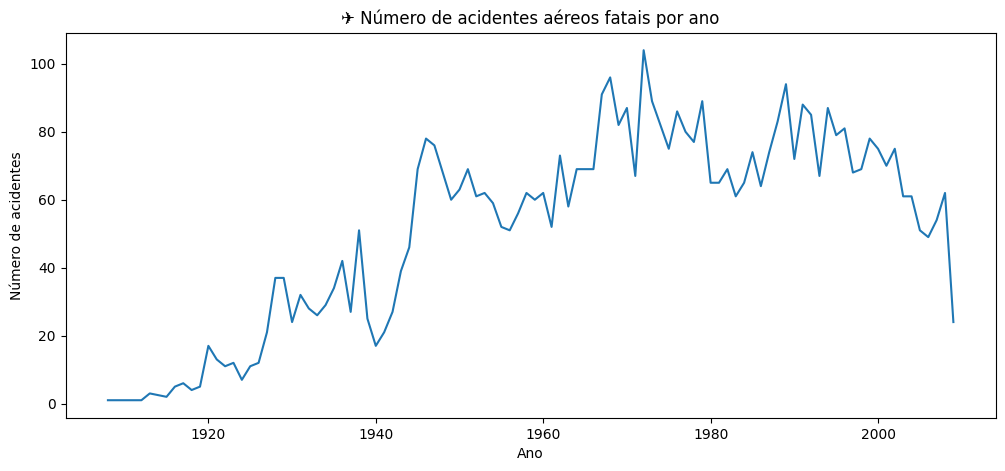

✈️ Ano com mais acidentes: 1972 (104 acidentes)
✈️ Ano com menos acidentes: 1908 (1 acidentes)

📋 Conclusões sobre acidentes:
✅ Apesar de apresentar muitas oscilações, pode-se notar certos padrões no comportamento do gráfico
✅ A partir de 1908, o número de acidentes fatais por ano aumentou, até atingir um pico em 1972
✅ Após 1972, o número de acidentes fatais passou a diminuir, mostrando tendência de queda na atualidade


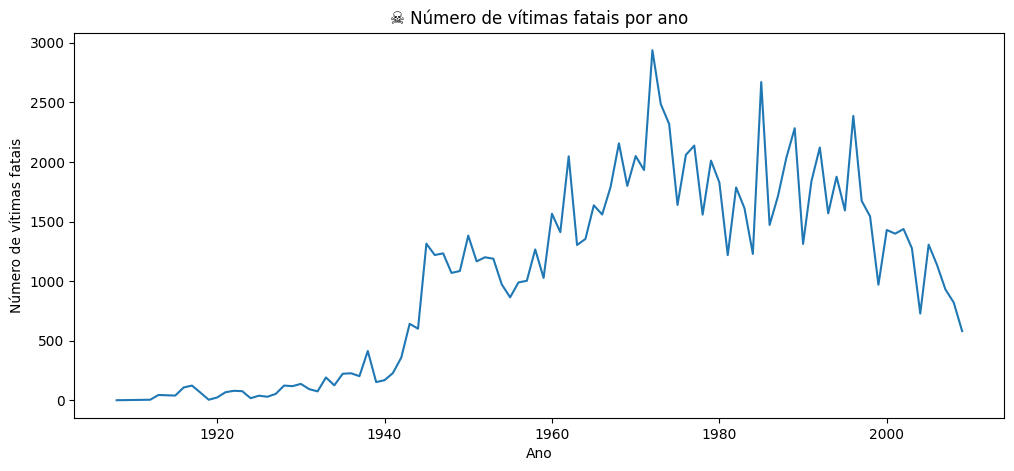

☠️ Ano com mais vítimas fatais: 1972 (2937.0 fatalidades)

📋 Conclusões sobre vítimas fatais:
✅ O gráfico das vítimas fatais segue padrão semelhante ao de acidentes
✅ O número de vítimas fatais aumentou até atingir um pico em 1972, depois diminuiu até os dias atuais


In [4]:
# Converter a coluna Date para datetime e extrair o ano
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df["Year"] = df["Date"].dt.year

# Número de acidentes por ano
acidentes_por_ano = df["Year"].value_counts().sort_index()

acidentes_por_ano.plot(figsize=(12,5))
plt.title("✈️ Número de acidentes aéreos fatais por ano")
plt.xlabel("Ano")
plt.ylabel("Número de acidentes")
plt.show()

# Ano com mais e menos acidentes
ano_mais_acidentes = acidentes_por_ano.idxmax()
ano_menos_acidentes = acidentes_por_ano.idxmin()

print(f"✈️ Ano com mais acidentes: {ano_mais_acidentes} ({acidentes_por_ano.max()} acidentes)")
print(f"✈️ Ano com menos acidentes: {ano_menos_acidentes} ({acidentes_por_ano.min()} acidentes)")

print("\n📋 Conclusões sobre acidentes:")
print("✅ Apesar de apresentar muitas oscilações, pode-se notar certos padrões no comportamento do gráfico")
print("✅ A partir de 1908, o número de acidentes fatais por ano aumentou, até atingir um pico em 1972")
print("✅ Após 1972, o número de acidentes fatais passou a diminuir, mostrando tendência de queda na atualidade")

# Número de vítimas fatais por ano
vítimas_por_ano = df.groupby("Year")["Fatalities"].sum().sort_index()

vítimas_por_ano.plot(figsize=(12,5))
plt.title("☠️ Número de vítimas fatais por ano")
plt.xlabel("Ano")
plt.ylabel("Número de vítimas fatais")
plt.show()

# Ano com mais vítimas fatais
ano_mais_vitimas = vítimas_por_ano.idxmax()
num_mais_vitimas = vítimas_por_ano.max()

print(f"☠️ Ano com mais vítimas fatais: {ano_mais_vitimas} ({num_mais_vitimas} fatalidades)")

print("\n📋 Conclusões sobre vítimas fatais:")
print("✅ O gráfico das vítimas fatais segue padrão semelhante ao de acidentes")
print("✅ O número de vítimas fatais aumentou até atingir um pico em 1972, depois diminuiu até os dias atuais")

### 👥 Pergunta 2: Quais os horários em que mais acontecem acidentes aérios? E em quais há mais vítimas fatais?
> **Hipótese:** Durante a noite, a visibilidade dos pilotos de aeronaves diminui consideravelmente, portanto espera-se que o número de acidentes aumente nessa faixa de horários.

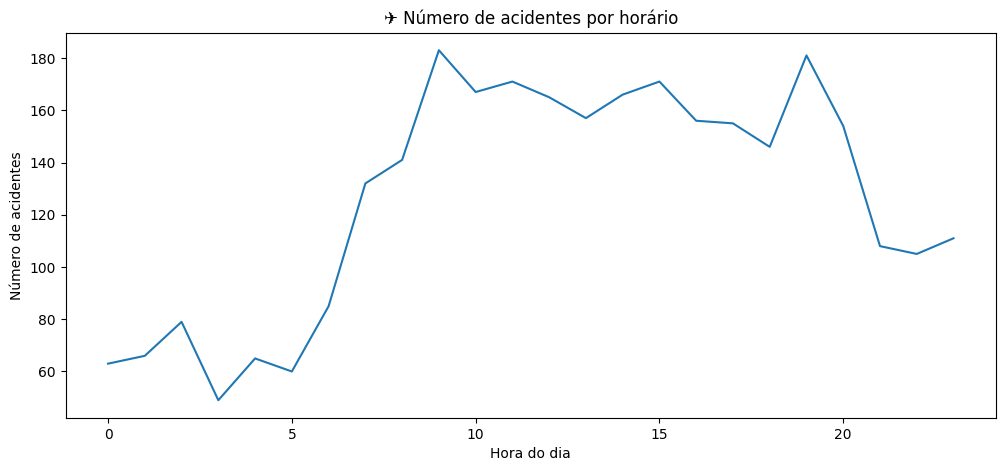

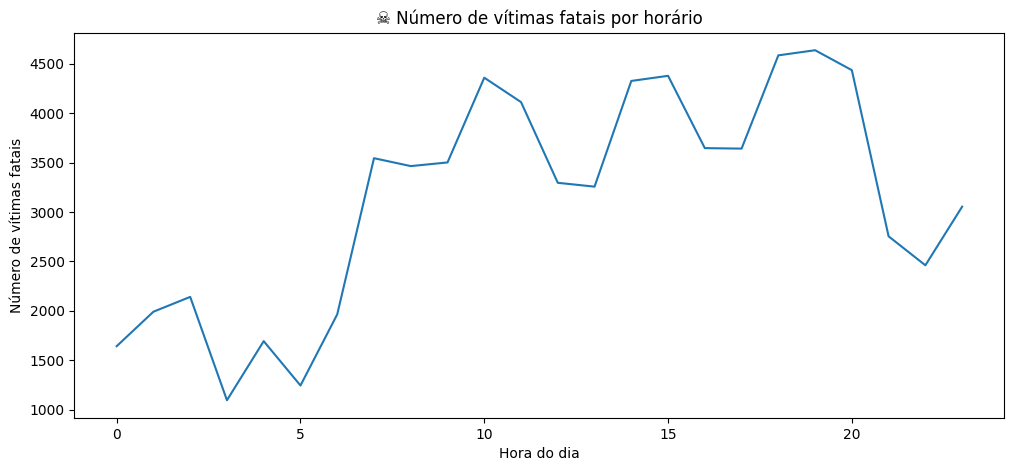

⏰ Hora com mais acidentes: 9h (183 acidentes)
⏰ Hora com mais vítimas fatais: 19h (4637 vítimas)

📋 Conclusões:
✅ O gráfico de acidentes mostra que a maior parte ocorre durante o dia, entre 8h e 18h
✅ O gráfico de vítimas fatais apresenta tendência semelhante, com picos em horários diurnos


In [10]:

# Criar uma cópia do dataframe
dfTemp = df.copy()

# Remover linhas onde Time é nulo
dfTemp = dfTemp.dropna(subset=["Time"])

# Filtrar apenas valores no formato HH:MM
dfTemp = dfTemp[dfTemp["Time"].str.match(r"^\d{1,2}:\d{2}$")]

# Extrair a hora
dfTemp["Hora"] = dfTemp["Time"].str.split(":").str[0].astype(int)

# Número de acidentes por hora
acidentes_por_hora = dfTemp.groupby("Hora").size().sort_index()

# Identificar hora com mais acidentes
hora_mais_acidentes = acidentes_por_hora.idxmax()
num_mais_acidentes = acidentes_por_hora.max()

acidentes_por_hora.plot(figsize=(12,5))
plt.title("✈️ Número de acidentes por horário")
plt.xlabel("Hora do dia")
plt.ylabel("Número de acidentes")
plt.show()

# Número de vítimas fatais por hora
vitimas_por_hora = dfTemp.groupby("Hora")["Fatalities"].sum().sort_index()

# Identificar hora com mais vítimas
hora_mais_vitimas = vitimas_por_hora.idxmax()
num_mais_vitimas = vitimas_por_hora.max()

vitimas_por_hora.plot(figsize=(12,5))
plt.title("☠️ Número de vítimas fatais por horário")
plt.xlabel("Hora do dia")
plt.ylabel("Número de vítimas fatais")
plt.show()

print(f"⏰ Hora com mais acidentes: {hora_mais_acidentes}h ({num_mais_acidentes} acidentes)")

print(f"⏰ Hora com mais vítimas fatais: {hora_mais_vitimas}h ({round(num_mais_vitimas)} vítimas)")

print("\n📋 Conclusões:")
print("✅ O gráfico de acidentes mostra que a maior parte ocorre durante o dia, entre 8h e 18h")
print("✅ O gráfico de vítimas fatais apresenta tendência semelhante, com picos em horários diurnos")


### 👥 Pergunta 3: Existe alguma relação entre o número de pessoas a bordo e o número de vítimas fatais?
> **Hipótese:**  Devido a letalidade observada em acidentes aéreos, é esperado que esta relação exista

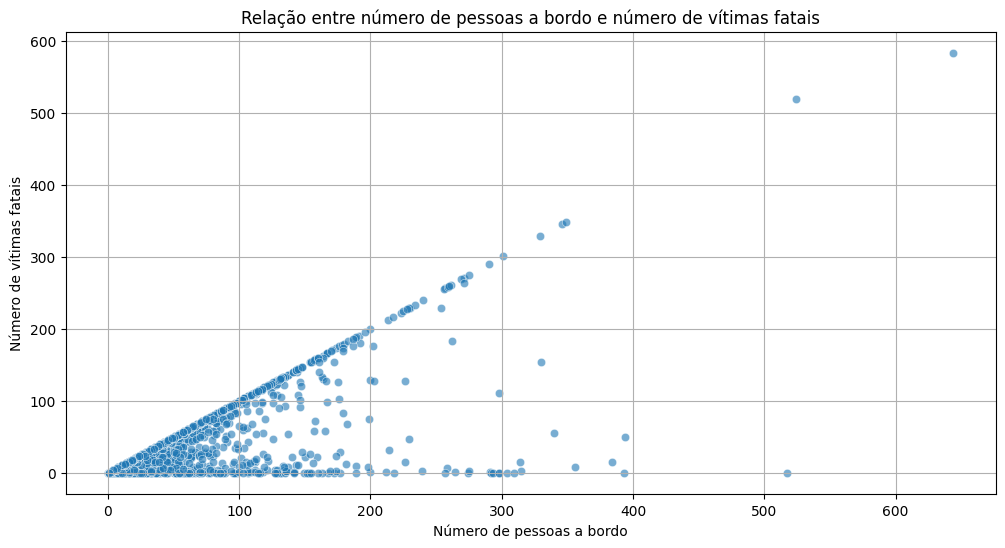

📊 Correlação entre pessoas a bordo e vítimas fatais: 0.76
✅ A correlação entre pessoas a bordo e vítimas fatais é alta
✅ O número de acidentes com um número menor de vítimas (100 ou menos) é bem maior que acidentes mais populosos


In [9]:
# Filtrar linhas válidas (sem valores nulos)
df_corr = df.dropna(subset=["Aboard", "Fatalities"])

# Criar gráfico de dispersão (scatter plot)
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df_corr,
    x="Aboard",
    y="Fatalities",
    alpha=0.6
)

plt.title("Relação entre número de pessoas a bordo e número de vítimas fatais")
plt.xlabel("Número de pessoas a bordo")
plt.ylabel("Número de vítimas fatais")
plt.grid(True)
plt.show()

# Calcular correlação
correlacao = df_corr["Aboard"].corr(df_corr["Fatalities"])
print(f"📊 Correlação entre pessoas a bordo e vítimas fatais: {correlacao:.2f}")
print(f"✅ A correlação entre pessoas a bordo e vítimas fatais é alta")
print(f"✅ O número de acidentes com um número menor de vítimas (100 ou menos) é bem maior que acidentes mais populosos")

### 👥 Pergunta 4: Quais os países com mais acidentes aéreos?
> **Hipótese:**  É esperado que locais com maior tráfego aéreo ou com condições climáticas mais severas apresentem maior propensão à ocorrência de acidentes aéreos.

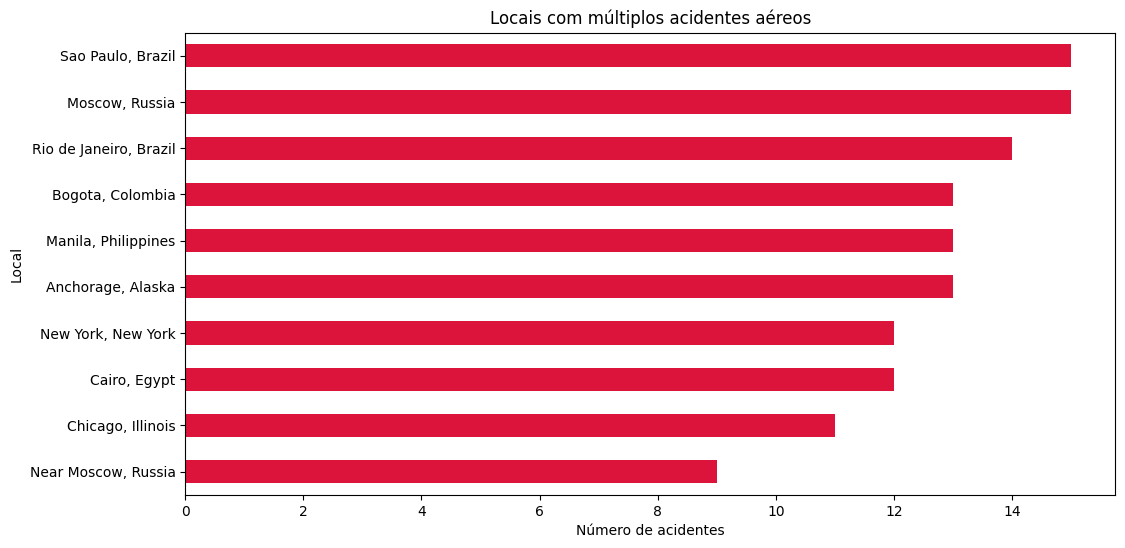

🏛️ Locais com mais de um acidente (top 10):
Location
Sao Paulo, Brazil         15
Moscow, Russia            15
Rio de Janeiro, Brazil    14
Bogota, Colombia          13
Manila, Philippines       13
Anchorage, Alaska         13
New York, New York        12
Cairo, Egypt              12
Chicago, Illinois         11
Near Moscow, Russia        9
Name: count, dtype: int64

✅ Entre os locais com múltiplos acidentes aéreos, estão cidades com grande tráfego aéreo, como São Paulo, Brazil.
✅ Também estão presentes locais com condições climáticas mais severas, como Anchorage, Alaska


In [11]:
# Contar número de acidentes por local
acidentes_por_local = df["Location"].value_counts()

# Filtrar apenas locais com mais de um acidente
locais_multiplos = acidentes_por_local[acidentes_por_local > 1]


# Plotar gráfico
locais_multiplos.head(10).plot(kind="barh", figsize=(12,6), color="crimson")
plt.title("Locais com múltiplos acidentes aéreos")
plt.xlabel("Número de acidentes")
plt.ylabel("Local")
plt.gca().invert_yaxis()  # inverte para que o maior fique no topo
plt.show()

# Mostrar os 10 locais com mais acidentes
print("🏛️ Locais com mais de um acidente (top 10):")
print(locais_multiplos.head(10))
print(f"\n✅ Entre os locais com múltiplos acidentes aéreos, estão cidades com grande tráfego aéreo, como São Paulo, Brazil.")
print(f"✅ Também estão presentes locais com condições climáticas mais severas, como Anchorage, Alaska")

---
# 📋 Resumo Geral da Análise — Airplane Crashes Since 1908

## 🗂️ Sobre o Dataset
- **Período coberto:** 17/09/1908 a 08/06/2009
- **Total de registros originais:** 5.268 acidentes aéreos
- **Registros utilizados na análise (após limpeza):** 5.246
- **Colunas relevantes mantidas:** Data, Horário, Localização, Operador, Pessoas a bordo e Fatalidades

---

## 📊 Principais Números

| Métrica | Valor |
|---|---|
| Total de fatalidades | **105.358** |
| Total de sobreviventes | **144.551** |
| Taxa de sobrevivência geral | **27,11%** |
| Ano com mais acidentes | **1972** (104 acidentes) |
| Ano com mais vítimas fatais | **1972** (2.937 fatalidades) |
| Hora com mais acidentes | **9h** (183 acidentes) |
| Hora com mais vítimas fatais | **19h** (4.637 vítimas) |
| Correlação bordo × fatalidades | **0,76** (alta) |

---

## 🔍 Respostas às Perguntas da Análise

### ✈️ 1. O número de acidentes aumentou ou diminuiu ao longo do tempo?
- O número de acidentes cresceu progressivamente desde 1908, atingindo seu **pico máximo em 1972** com 104 ocorrências.
- Após 1972, há uma **tendência consistente de queda**, refletindo o impacto dos avanços tecnológicos e dos protocolos de segurança aérea.
- O número de vítimas fatais acompanha o mesmo padrão, também com pico em 1972 (2.937 mortes) e queda gradual nos anos seguintes.
- **Conclusão:** A hipótese inicial foi confirmada — a aviação ficou mais segura ao longo do tempo.

### ⏰ 2. Quais horários concentram mais acidentes e vítimas fatais?
- A maioria dos acidentes ocorre durante o **período diurno**, especialmente entre **8h e 18h**.
- O horário com maior número de acidentes é às **9h** (183 ocorrências).
- O horário com maior número de vítimas fatais é às **19h** (4.637 vítimas), no início da noite.
- **Conclusão:** A hipótese de que a noite seria mais perigosa **não foi confirmada**. Os acidentes são mais frequentes durante o dia, quando o tráfego aéreo é mais intenso.

### 🌍 3. Quais locais registram mais acidentes?
- **São Paulo (Brasil)** e **Moscou (Rússia)** lideram com 15 acidentes cada.
- Rio de Janeiro aparece em 3º lugar com 14 ocorrências.
- Também se destacam **Bogotá (Colômbia)**, **Manila (Filipinas)** e **Anchorage (Alaska)**.
- Esses locais se explicam pela combinação de **alto tráfego aéreo** e/ou **condições climáticas adversas**.

---

## 🔗 Correlação: Pessoas a Bordo × Vítimas Fatais
- Foi identificada uma **correlação positiva alta (0,76)** entre o número de pessoas a bordo e o número de fatalidades.
- A grande maioria dos acidentes envolve **100 ou menos vítimas**, sendo acidentes com muitas vítimas eventos bem menos frequentes.

---

## ✅ Considerações Finais
> A análise demonstrou que, apesar de o número absoluto de vols ter crescido muito ao longo do século XX, a **segurança da aviação melhorou significativamente** após a década de 1970. Os acidentes são predominantemente diurnos — relacionados ao volume de tráfego — e os locais mais afetados são grandes centros urbanos com alta movimentação aeroportuária. O transporte aéreo, historicamente, evoluiu para se tornar um dos meios de transporte mais seguros do mundo.
